<a href="https://colab.research.google.com/github/mehrabbzz/Computer-Vision-Learning/blob/main/Image_Preprocessing(Enhancement).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image

# Replace with the actual path to your image file in Google Drive
image = '/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0001.jpg'

try:
    img = Image.open(image_path)
    print(f"Image loaded successfully from {image_path}")
    print(f"Image format: {img.format}")
    print(f"Image size: {img.size}")
    # You can now work with the 'img' object
    # For example, to display it:
    # from IPython.display import display
    # display(img)
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")

Image loaded successfully from /content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0001.jpg
Image format: JPEG
Image size: (512, 512)


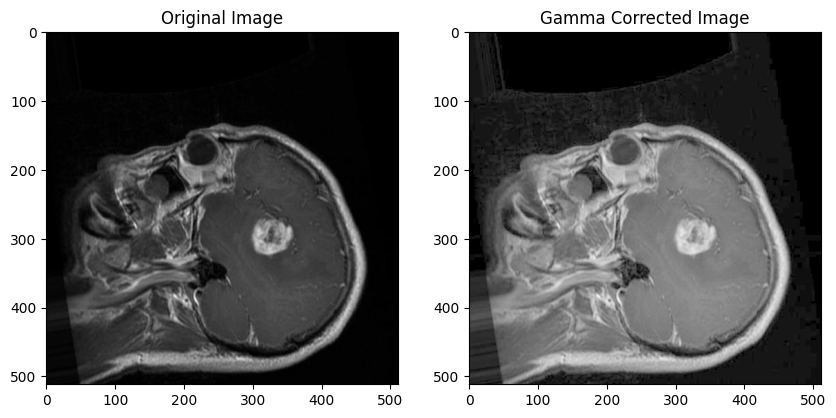

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gamma_correction(image, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

# Load image
image = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg')
gamma_corrected = gamma_correction(image, gamma=2.0)

# Display the result
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Gamma Corrected Image')
plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.show()


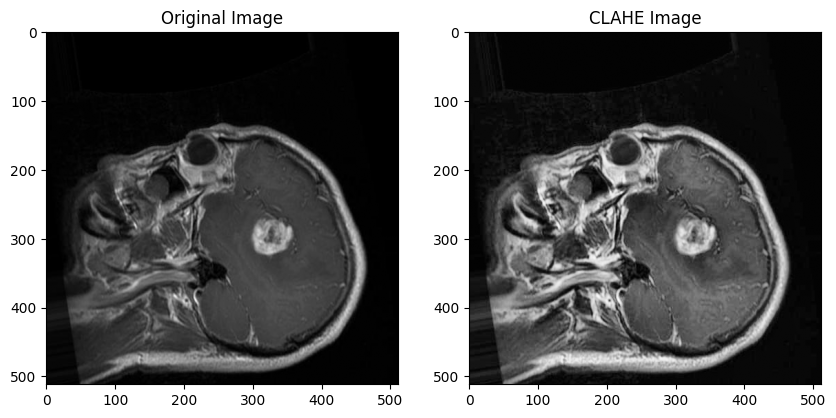

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt # Added this line
def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if image is not None: # Check if image was loaded successfully
        if len(image.shape) == 2:
            return clahe.apply(image)
        elif len(image.shape) == 3:
            channels = cv2.split(image)
            clahe_channels = [clahe.apply(ch) for ch in channels]
            return cv2.merge(clahe_channels)
    else:
        return None # Handle the case where image is None

# Load image. Make sure 'image_path' is correct.
image_path = '/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg'
#image_path = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = cv2.imread(image_path, 0)
clahe_image = clahe(image)

# Display the result
if clahe_image is not None: # Check if CLAHE was applied successfully
    plt.figure(figsize=(10,5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title('CLAHE Image')
    plt.imshow(clahe_image, cmap='gray')
    plt.show()
else:
    print("Failed to load or apply CLAHE to the image. Check the file path.")

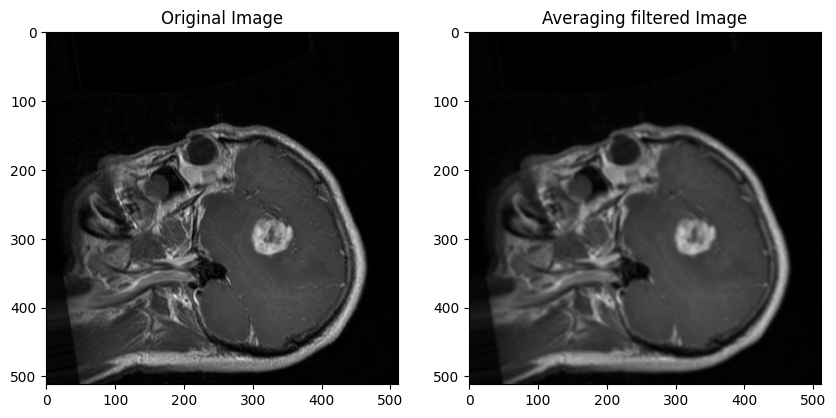

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

image = cv.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg')

avg = cv.blur(image,(5,5))

# Display the result
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Averaging filtered Image')
plt.imshow(cv.cvtColor(avg, cv.COLOR_BGR2RGB))
plt.show()

# Image Noise

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

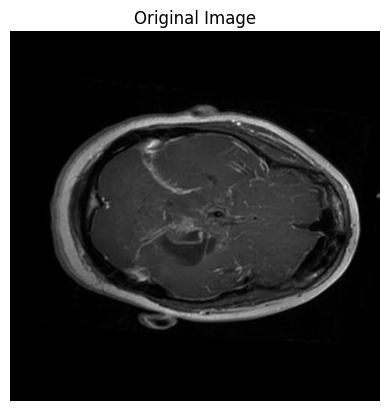

In [ ]:
from PIL import Image

# If it's a local file path, use this:
img = Image.open('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0011.jpg')

img = np.array(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

Adding Gaussian noise

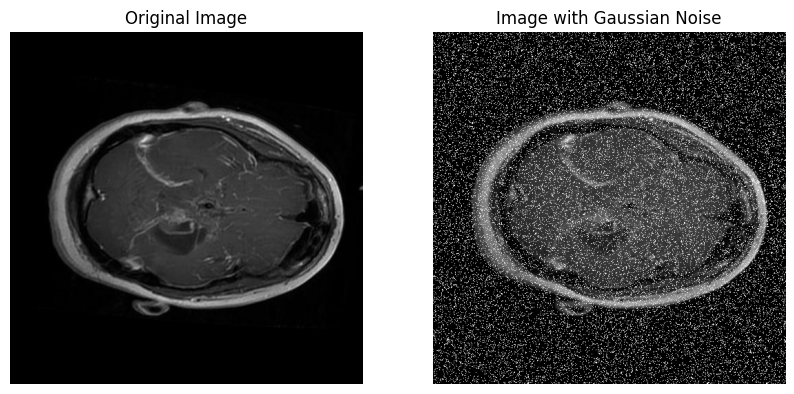

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, sigma=.5):
    """
    Add Gaussian noise to an image.

    Parameters:
    - image: The input image to which noise is added.
    - mean: The mean of the Gaussian distribution .
    - sigma: The standard deviation of the Gaussian distribution .

    Returns:
    - noisy_image: The image with added Gaussian noise.
    """
    # Generate Gaussian noise
    gaussian_noise = np.random.normal(mean, sigma, image.shape).astype('uint8')

    # Add the noise to the original image
    noisy_image = cv2.add(image, gaussian_noise)

    return noisy_image

# Load image in grayscale
image = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0011.jpg', cv2.IMREAD_GRAYSCALE)

# Add Gaussian noise to the image
noisy_image = add_gaussian_noise(image, mean=0, sigma=.8)

# Display input and output images side by side
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')  # Hide axes for cleaner display
plt.subplot(1, 2, 2)
plt.title('Image with Gaussian Noise')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')  # Hide axes for cleaner display
plt.show()

# how do i find image pixel range?

In [ ]:
import numpy as np

if 'noisy_image' in locals():
    min_pixel_value = np.min(noisy_image)
    max_pixel_value = np.max(noisy_image)
    print(f"Minimum pixel value in noisy_image: {min_pixel_value}")
    print(f"Maximum pixel value in noisy_image: {max_pixel_value}")
    print(f"The pixel range is from {min_pixel_value} to {max_pixel_value}.")
else:
    print("Error: 'noisy_image' not found. Please ensure the Gaussian noise cell was executed successfully.")

Minimum pixel value in noisy_image: 0
Maximum pixel value in noisy_image: 255
The pixel range is from 0 to 255.


##Morphological Operation

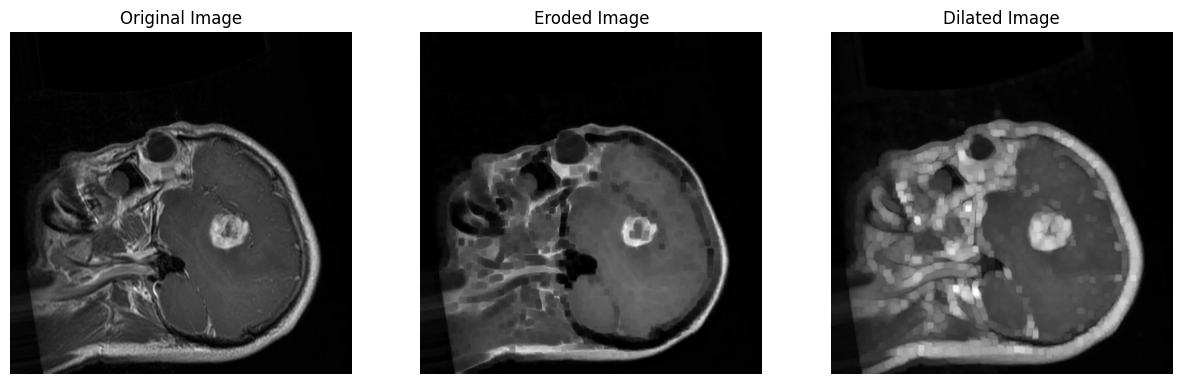

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

# Define the kernel
kernel = np.ones((7, 7), np.uint8)

# Perform all morphological operations
erosion = cv.erode(img, kernel, iterations=1)
dilation = cv.dilate(img, kernel, iterations=1)

# Display all the images side by side
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Eroded image
plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

# Dilated image
plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

# Show the images
plt.show()

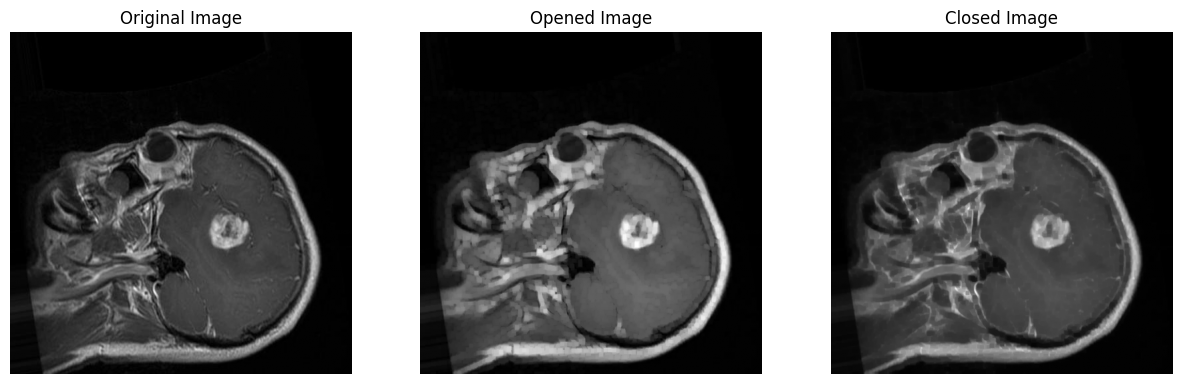

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

# Define the kernel
kernel = np.ones((5,5), np.uint8)

opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)
closing = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)

# Display all the images side by side
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Opened image
plt.subplot(2, 3, 2)
plt.imshow(opening, cmap='gray')
plt.title('Opened Image')
plt.axis('off')

# Closed image
plt.subplot(2, 3, 3)
plt.imshow(closing, cmap='gray')
plt.title('Closed Image')
plt.axis('off')

# Show the images
plt.show()

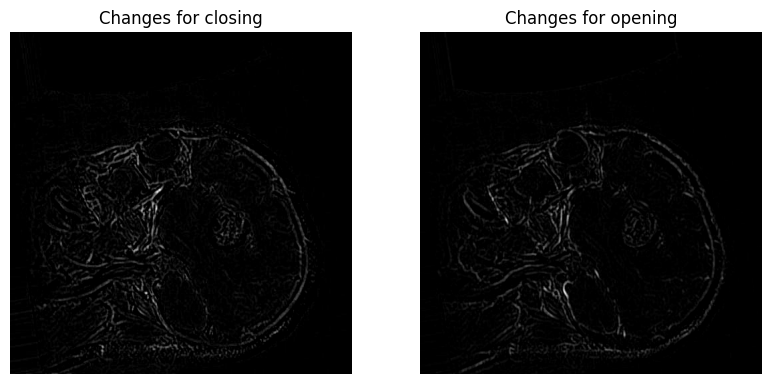

In [ ]:
from google.colab.patches import cv2_imshow
im2 = closing-img
im3 = img - opening

# Display all the images side by side
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(im2, cmap='gray')
plt.title('Changes for closing')
plt.axis('off')

# Opened image
plt.subplot(2, 3, 2)
plt.imshow(im3, cmap='gray')
plt.title('Changes for opening')
plt.axis('off')

# Show the images
plt.show()

# Image Transformation

Scaling

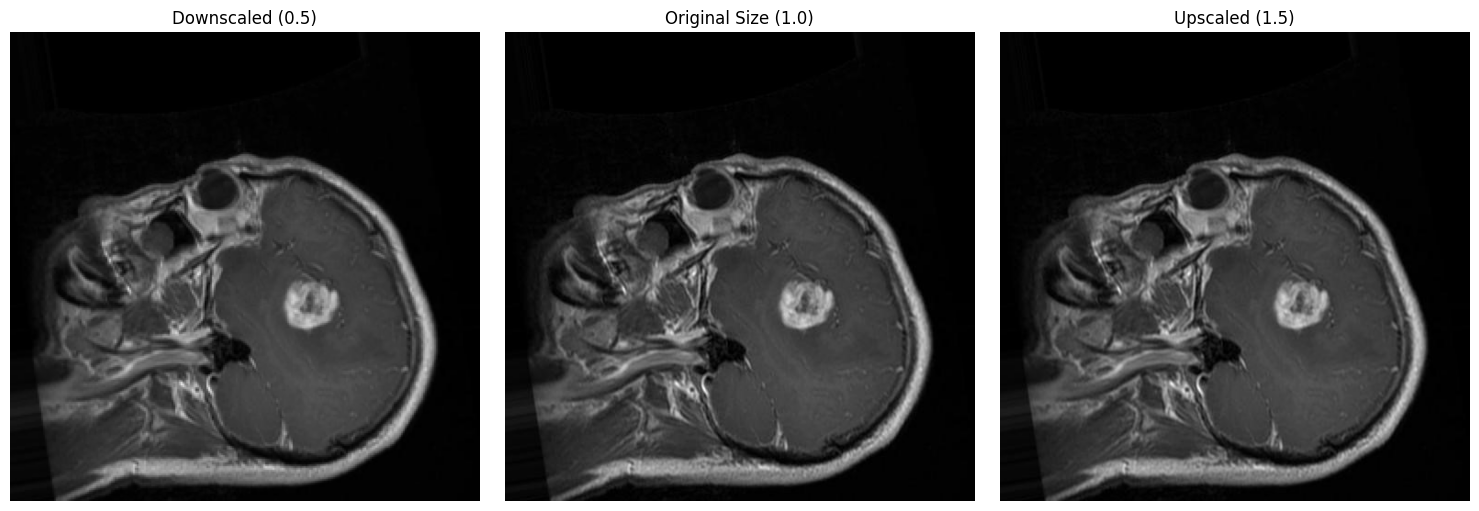

In [ ]:
import cv2
import matplotlib.pyplot as plt

def scale_image(image, scale_factor):
    width = int(image.shape[1] * scale_factor)
    height = int(image.shape[0] * scale_factor)
    dim = (width, height)
    scaled_image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)
    return scaled_image

# Example: Load an image and create scaled versions
img = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg')  # Replace with your image path
scaled_img_1 = scale_image(img, 0.5)  # Downscaled
scaled_img_2 = scale_image(img, 1.0)  # Original size (no scaling)
scaled_img_3 = scale_image(img, 2)  # Upscaled

# Plot images side by side
plt.figure(figsize=(15, 5))  # Adjust the figure size

# First image
plt.subplot(1, 3, 1)  # 1 row, 3 columns, position 1
plt.imshow(cv2.cvtColor(scaled_img_1, cv2.COLOR_BGR2RGB))
plt.title('Downscaled (0.5)')
plt.axis('off')

# Second image
plt.subplot(1, 3, 2)  # 1 row, 3 columns, position 2
plt.imshow(cv2.cvtColor(scaled_img_2, cv2.COLOR_BGR2RGB))
plt.title('Original Size (1.0)')
plt.axis('off')

# Third image
plt.subplot(1, 3, 3)  # 1 row, 3 columns, position 3
plt.imshow(cv2.cvtColor(scaled_img_3, cv2.COLOR_BGR2RGB))
plt.title('Upscaled (1.5)')
plt.axis('off')

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
# Function to calculate the total number of pixels in an image
def get_pixel_count(image):
    return image.shape[0] * image.shape[1]

# Calculate pixel counts
pixel_count_1 = get_pixel_count(scaled_img_1)  # Downscaled image
pixel_count_2 = get_pixel_count(scaled_img_2)  # Original size image
pixel_count_3 = get_pixel_count(scaled_img_3)  # Upscaled image

# Display pixel counts
print(f"Pixel count of Downscaled (0.5): {pixel_count_1}")
print(f"Pixel count of Original Size (1.0): {pixel_count_2}")
print(f"Pixel count of Upscaled (1.5): {pixel_count_3}")

Pixel count of Downscaled (0.5): 65536
Pixel count of Original Size (1.0): 262144
Pixel count of Upscaled (1.5): 1048576


Rotation

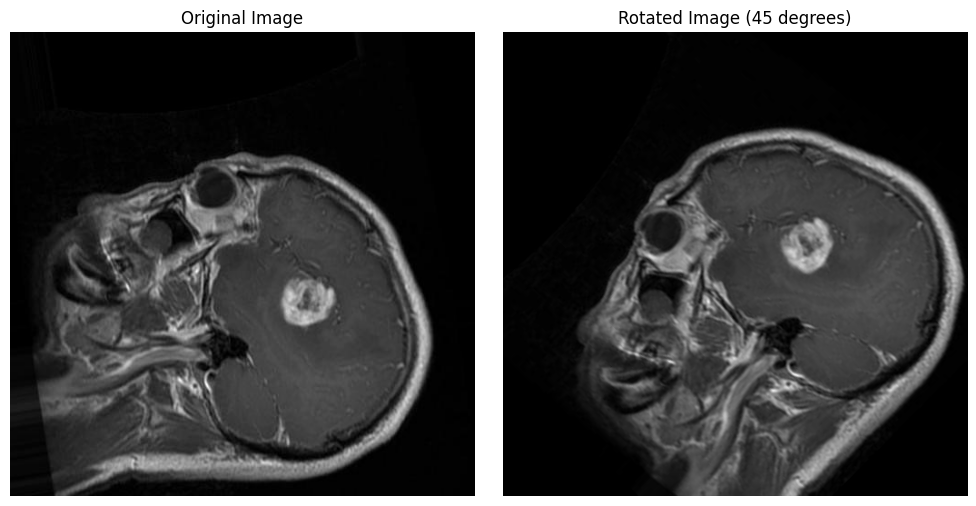

In [ ]:
import cv2
import matplotlib.pyplot as plt

def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, matrix, (w, h))
    return rotated_image

# Load the original image
img = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg')  # Replace with your image path

# Rotate the image by 45 degrees
rotated_img = rotate_image(img, 45)

# Plot the original and rotated images
plt.figure(figsize=(10, 5))  # Adjust figure size

# Original image
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Rotated image
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
plt.title('Rotated Image (45 degrees)')
plt.axis('off')

# Display the plot
plt.tight_layout()
plt.show()


Flipping

Flipping an image can be done horizontally or vertically using OpenCV's flip function.

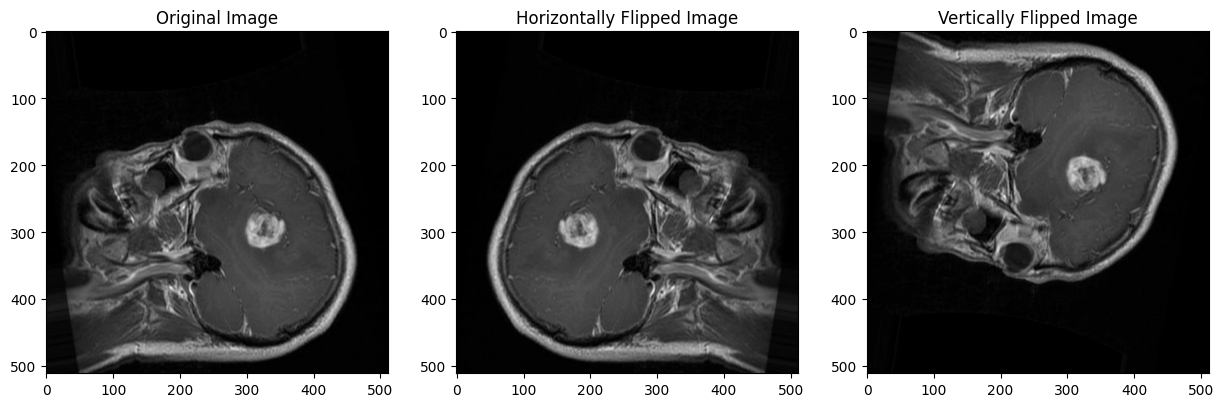

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg')  # Replace with your image path

# Horizontal flip
flipped_image_h = cv2.flip(img, 1)
# Vertical flip
flipped_image_v = cv2.flip(img, 0)

# Display input and output images side by side
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray') # Displaying original color image as grayscale
plt.subplot(1, 3, 2)
plt.title('Horizontally Flipped Image')
plt.imshow(flipped_image_h, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Vertically Flipped Image')
plt.imshow(flipped_image_v, cmap='gray')
plt.show()

Zooming

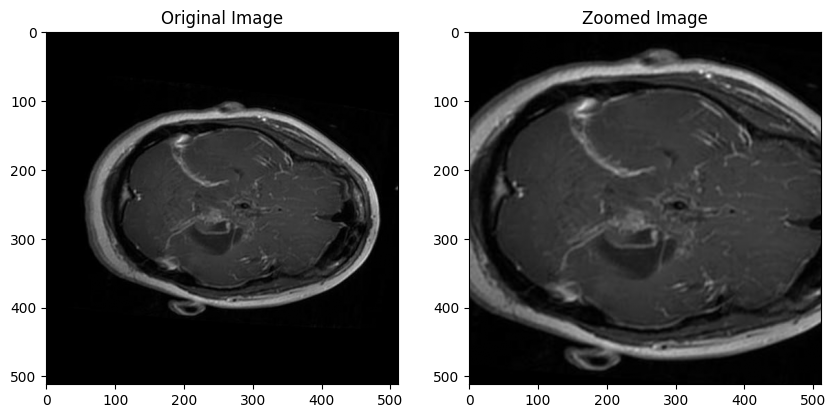

In [ ]:
def zoom_image(image, zoom_factor):
    height, width = image.shape[:2]
    # Calculate cropping coordinates
    new_height, new_width = int(height / zoom_factor), int(width / zoom_factor)
    top = (height - new_height) // 2
    left = (width - new_width) // 2
    bottom = top + new_height
    right = left + new_width

    # Crop and resize the image
    cropped_image = image[top:bottom, left:right]
    zoomed_image = cv2.resize(cropped_image, (width, height), interpolation=cv2.INTER_LINEAR)
    return zoomed_image

image = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0011.jpg', cv2.IMREAD_GRAYSCALE)
zoomed_image = zoom_image(image, 1.5)

# Display input and output images side by side
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Zoomed Image')
plt.imshow(zoomed_image, cmap='gray')
plt.show()

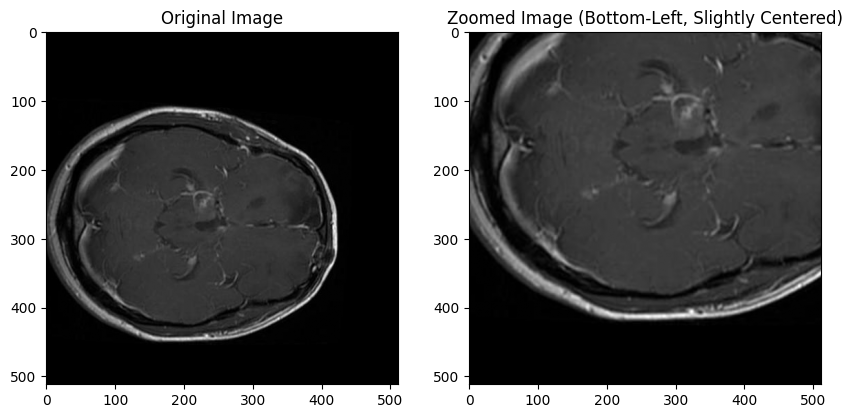

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def zoom_image(image, zoom_factor, region='bottom_left_slightly_centered'):
    height, width = image.shape[:2]

    if region == 'bottom_left_slightly_centered':
        # Define the new region closer to the center of the bottom-left corner
        new_height, new_width = int(height / zoom_factor), int(width / zoom_factor)

        # Adjust the top and left positions to zoom slightly to the center
        top = height - new_height  # Start from the bottom

        # Adjust left position to crop 30% from the right
        left = width - new_width - int(width * 0.3)  # Move 30% from the right

    # Crop the image based on the region
    cropped_image = image[top:top+new_height, left:left+new_width]

    # Resize the cropped image back to original size (zoom effect)
    zoomed_image = cv2.resize(cropped_image, (width, height), interpolation=cv2.INTER_LINEAR)

    return zoomed_image

# Load image in grayscale
image = cv2.imread('/content/drive/MyDrive/Brain_Cancer/brain_glioma/brain_glioma_0014.jpg', cv2.IMREAD_GRAYSCALE)

# Zoom into the bottom-left region close to the center
zoomed_image = zoom_image(image, zoom_factor=1.5, region='bottom_left_slightly_centered')

# Display input and output images side by side
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Zoomed Image (Bottom-Left, Slightly Centered)')
plt.imshow(zoomed_image, cmap='gray')
plt.show()